# CycleGAN — actual saved run evidence

Srinidhi, Lab Pair 49. This notebook **summarizes a saved completed training run and held-out evaluation**. Its executed cells verify and read actual artifacts; they do not train the models. The exact recorded training/evaluation commands and resolved configuration are displayed below. Human ratings and Kaggle results remain pending; this is not a claim that every lab requirement is complete.

In [1]:
from pathlib import Path
import csv
import hashlib
import json
import pandas as pd
from IPython.display import display, Image
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "publication.json").is_file())
manifest = json.loads((ROOT / "publication.json").read_text())
for relative, info in manifest["files"].items():
    sha = hashlib.sha256()
    with (ROOT / relative).open("rb") as stream:
        for block in iter(lambda: stream.read(1024 * 1024), b""):
            sha.update(block)
    assert sha.hexdigest() == info["sha256"], relative
print("Verified", len(manifest["files"]), "saved evidence files.")
OUT = ROOT / "outputs/full"
provenance = json.loads((OUT / "run_summary.json").read_text())
assert provenance["status"] == "completed" and provenance["summary"]["class_results"]
print("Training environment (not this notebook's execution machine)")
display(provenance["environment"])
print("Resolved training configuration")
display(json.loads((OUT / "resolved_config.json").read_text()))
data = json.loads((OUT / "data_manifest.json").read_text())
display({"split_counts": data["counts"], "manifest_fingerprint": data["manifest_fingerprint"],
         "checkpoint_sha256": manifest["checkpoint_sha256"]})
commands = json.loads((OUT / "commands.json").read_text())
print("Exact recorded training commands:")
print("\n".join(commands["training"]))
print("Exact recorded evaluation command:")
print(commands["evaluation"])

Verified 3015 saved evidence files.
Training environment (not this notebook's execution machine)


{'captured_utc': '2026-09-19T21:03:24.744973+00:00',
 'python': '3.12.3',
 'platform': 'Linux-5.15.0-191-generic-x86_64-with-glibc2.39',
 'machine': 'x86_64',
 'packages': {'torch': '2.11.0+cu128',
  'torchvision': '0.26.0+cu128',
  'numpy': '2.5.3',
  'pandas': '3.0.6',
  'scikit-learn': '1.9.1',
  'scipy': '1.16.3',
  'matplotlib': '3.11.2',
  'datasets': '5.0.1',
  'Pillow': '12.3.0',
  'clean-fid': '0.1.35',
  'lpips': '0.1.4',
  'prdc': '0.2'},
 'cuda_available': True,
 'cuda_build': '12.8',
 'cudnn': 91900,
 'gpus': [{'index': 0,
   'name': 'NVIDIA GeForce RTX 5090',
   'memory_bytes': 33668857856,
   'compute_capability': [12, 0]}],
 'mps_available': False,
 'nvidia_smi': 'name, uuid, driver_version, memory.total [MiB]\nNVIDIA GeForce RTX 5090, GPU-df52819f-f1ff-484e-4af6-8f6202c1035c, 580.159.03, 32607 MiB'}

Resolved training configuration


{'mode': 'full',
 'seed': 2342,
 'image_size': 256,
 'base_channels': 64,
 'residual_blocks': 9,
 'batch_size': 1,
 'learning_rate': 0.0001,
 'betas': [0.5, 0.999],
 'cycle_weight': 10.0,
 'identity_weight': 5.0,
 'replay_size': 50,
 'epochs': 30,
 'constant_epochs': 15,
 'max_steps': None,
 'checkpoint_every': 500,
 'log_every': 50,
 'allow_synthetic': False,
 'select_best': True,
 'validation_every_epochs': 5,
 'evaluate_after_run': False,
 'evaluation': {'allow_metric_downloads': True,
  'max_images': None,
  'batch_size': 16,
  'kid_subsets': 50,
  'kid_subset_size': 100,
  'prdc_k': 5,
  'seed': 2342},
 'data': {'monet_dir': 'task3_gan/data/monet_jpg',
  'photo_dir': 'task3_gan/data/photo_jpg',
  'manifest_dir': 'task3_gan/srinidhi/data_processed/part3_manifests',
  'source_note': 'Verified class ZIP SHA256 5060b62d4a6a0194de10b849ea43b649f308ae516f0bf659b62ee404ca153e1d; unique-content independent 80/10/10 splits frozen at seed 2342; source receipts in reproducibility/manifests/s

{'split_counts': {'train_photo': 5624,
  'val_photo': 702,
  'test_photo': 702,
  'train_monet': 240,
  'val_monet': 30,
  'test_monet': 30},
 'manifest_fingerprint': '35184a0643321f99efc8df06544328b25c3364b66f29c76545ab47e01fe3438a',
 'checkpoint_sha256': 'd8b37673ce3cbda3397740863fcde33126eb029a9cc5a7c7cdde9dcf064d9b7e'}

Exact recorded training commands:
.venv/bin/python -u scripts/run_part3_colab.py --output reproducibility/raw_logs/srinidhi/vast-part3/full --until-step 200
.venv/bin/python -u scripts/run_part3_colab.py --output reproducibility/raw_logs/srinidhi/vast-part3/full --resume reproducibility/raw_logs/srinidhi/vast-part3/full/last.pt
Exact recorded evaluation command:
.venv/bin/python -u task3_gan/srinidhi/evaluate_local.py --mode full --device cuda --checkpoint reproducibility/raw_logs/srinidhi/vast-part3/full/best.pt --split test --output-dir reproducibility/raw_logs/srinidhi/vast-part3/evaluation-final --report reproducibility/raw_logs/srinidhi/vast-part3/evaluation-final/full_metrics_report.csv


In [2]:
metrics = pd.read_csv(ROOT / "metrics_report.csv", keep_default_na=False)
with pd.option_context("display.max_rows", None, "display.max_colwidth", 100):
    display(metrics[["scope", "direction", "metric", "value", "status", "details"]])
print("Pending entries are not measurements and are not zero.")

,scope,direction,metric,value,status,details
0,test,photo_to_monet,fid,195.82003626484618,computed,{}
1,test,photo_to_monet,kid,0.011112085897475482,computed,"{""note"": ""Subset SD is not training-seed uncertainty; unbiased KID estimates may be negative"", ""..."
2,test,photo_to_monet,precision,0.6011396011396012,computed,"{""nearest_k"": 5}"
3,test,photo_to_monet,recall,0.6333333333333333,computed,"{""nearest_k"": 5}"
4,test,photo_to_monet,density,0.5196581196581197,computed,"{""nearest_k"": 5}"
5,test,photo_to_monet,coverage,1.0,computed,"{""nearest_k"": 5}"
6,test,photo_to_monet,lpips_cycle,0.18855660488335496,computed,"{""count"": 702}"
7,test,photo_to_monet,content_cosine,0.8103030257754855,computed,"{""count"": 702}"
8,test,photo_to_monet,cycle_l1,0.09750508292023613,computed,"{""count"": 702, ""pixel_range"": ""[-1,1]""}"
9,test,photo_to_monet,source_count,702,computed,{}


Pending entries are not measurements and are not zero.


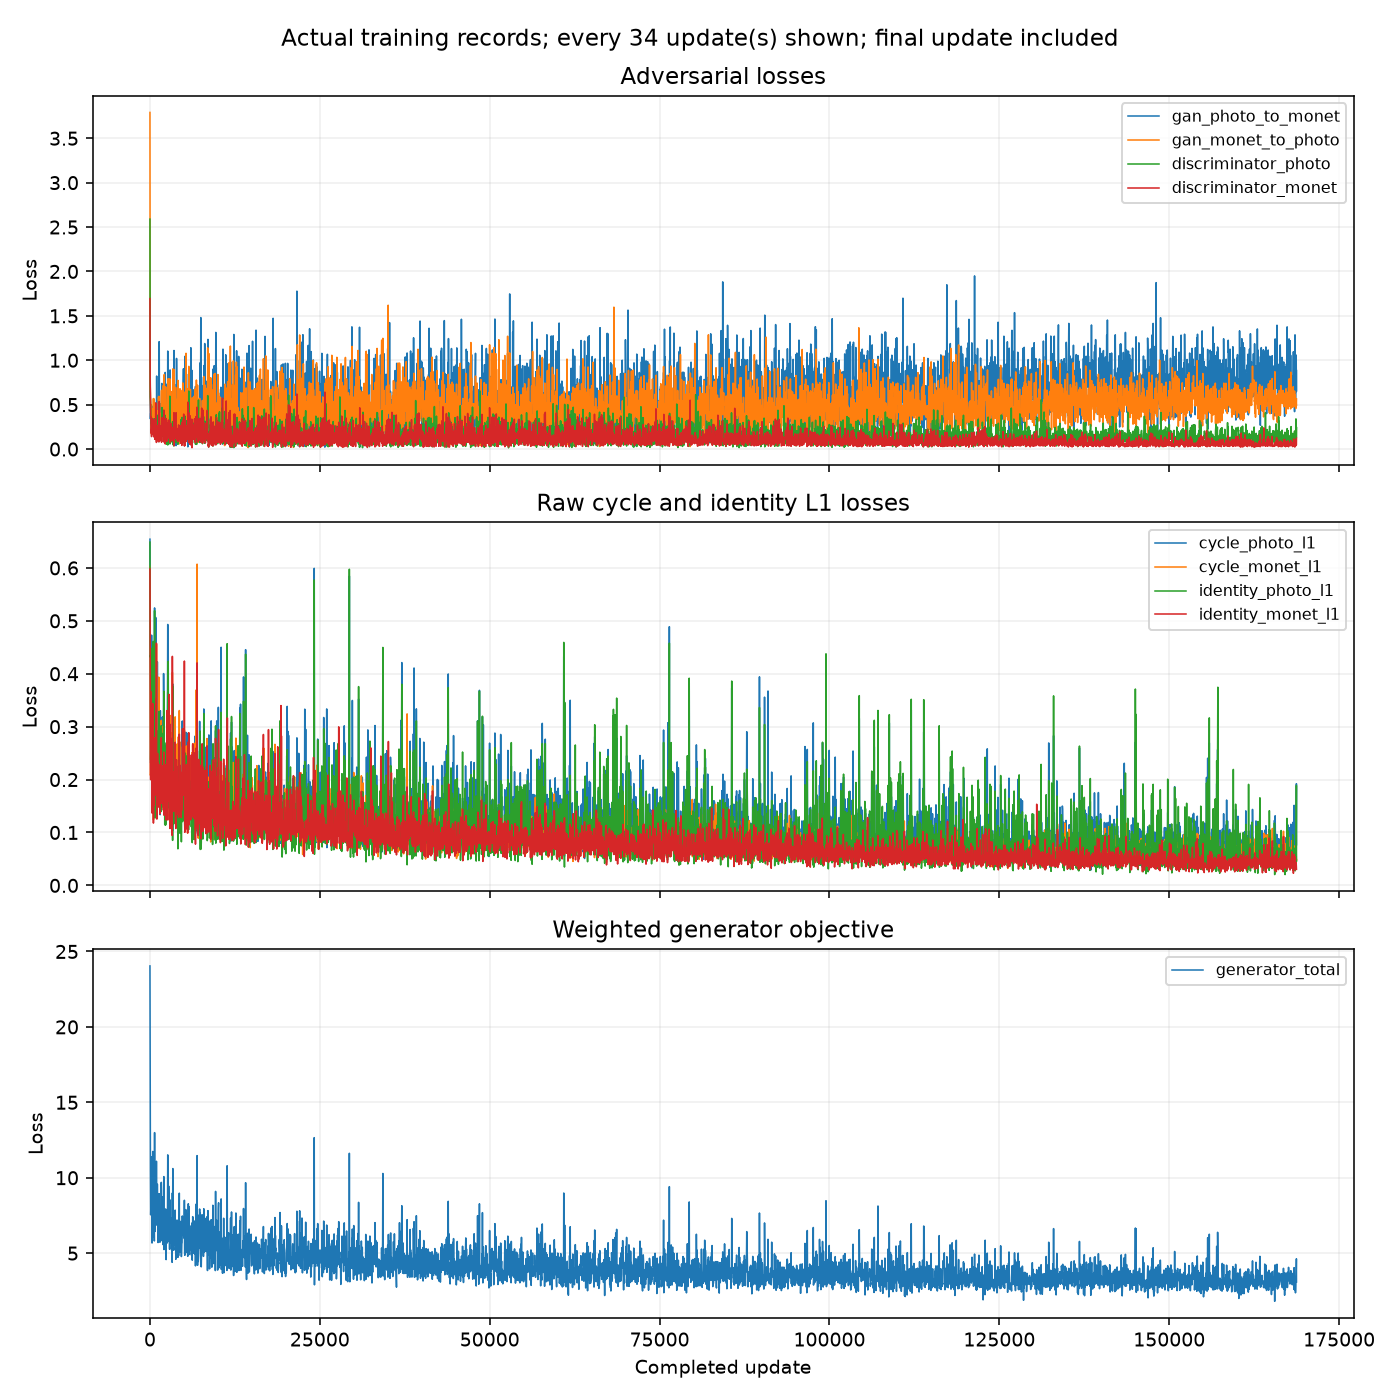

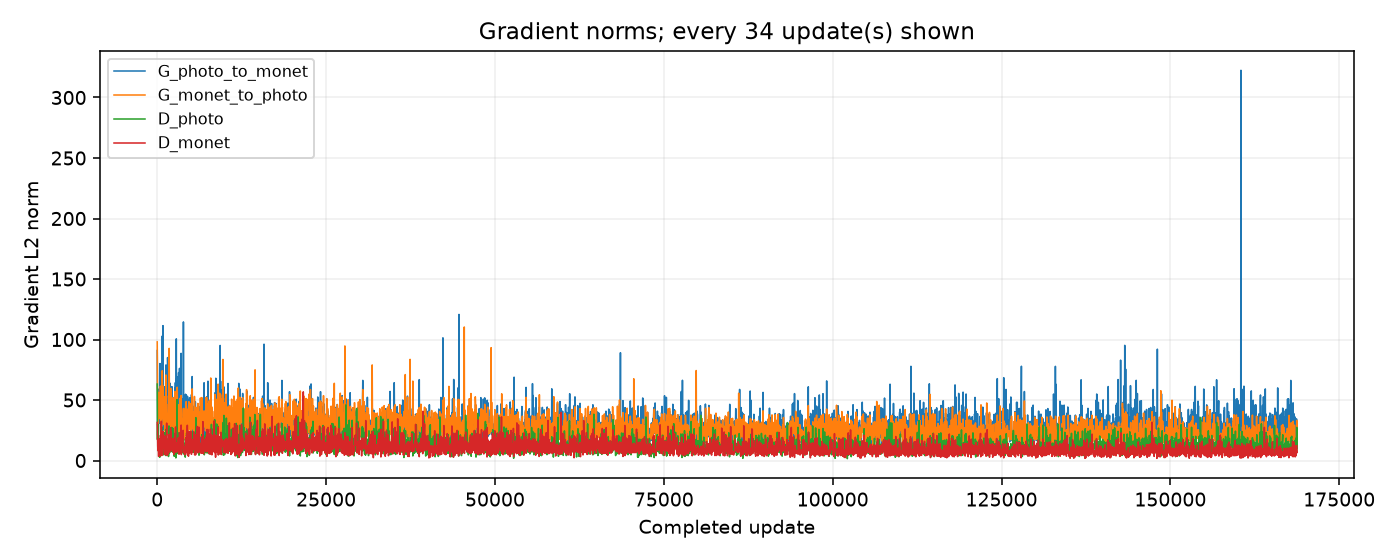

In [3]:
for name in ("loss_curves.png", "gradient_curves.png"):
    display(Image(filename=str(OUT / "figures" / name), width=950))

## Fixed inspection examples

The first three saved examples in each direction are shown deterministically. They are inspection examples, not a hand-picked competition submission. Cycle images reconstruct the original source; unpaired real targets are not image-level ground truth.

photo_to_monet
Saved sample 000000 — source, translation, reconstruction


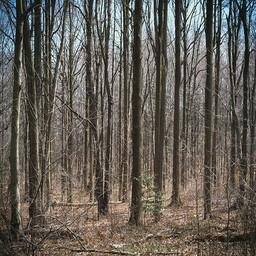

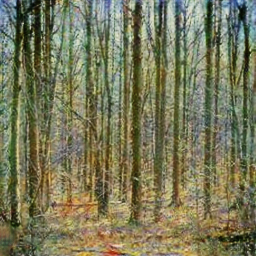

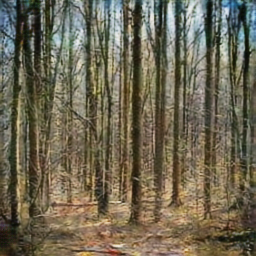

Saved sample 000001 — source, translation, reconstruction


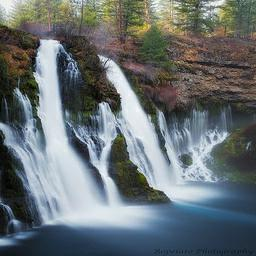

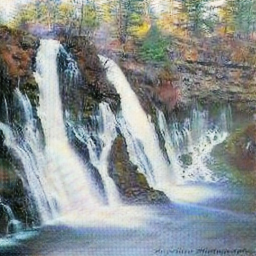

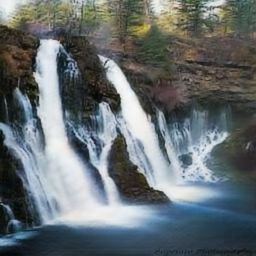

Saved sample 000002 — source, translation, reconstruction


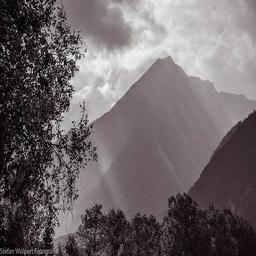

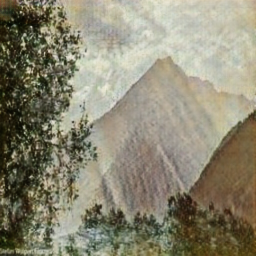

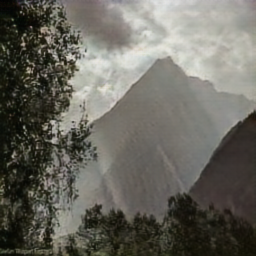

monet_to_photo
Saved sample 000000 — source, translation, reconstruction


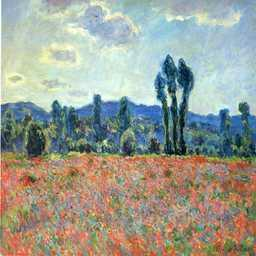

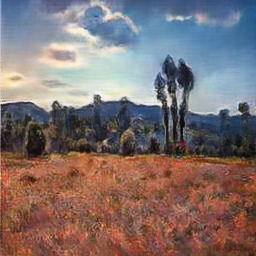

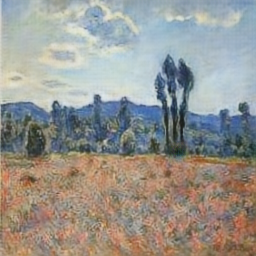

Saved sample 000001 — source, translation, reconstruction


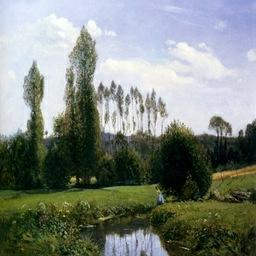

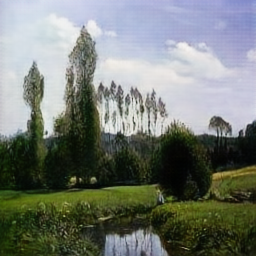

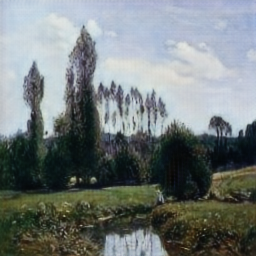

Saved sample 000002 — source, translation, reconstruction


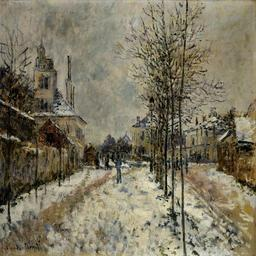

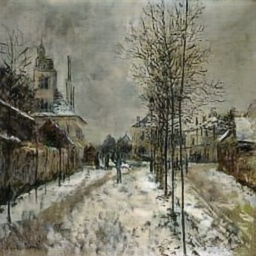

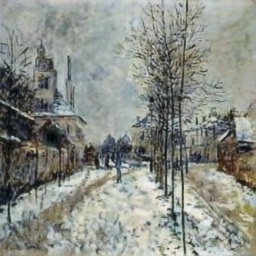

In [4]:
for direction in ("photo_to_monet", "monet_to_photo"):
    folder = OUT / "evaluation" / direction
    print(direction)
    for generated in sorted((folder / "generated").glob("*.png"))[:3]:
        print("Saved sample", generated.stem, "— source, translation, reconstruction")
        for label in ("source", "generated", "cycle"):
            display(Image(filename=str(folder / label / generated.name), width=256))

## Preserved raw console logs

The complete byte-identical logs and source hashes are retained. Only the final 4,000 characters of each console log are displayed here.

In [5]:
for log in sorted((OUT / "raw_logs").glob("run_*/RUN_LOG.txt")):
    print(log.relative_to(ROOT))
    print(log.read_text()[-4000:])
print("Human audit: two genuine independent raters are still required.")
print("Kaggle: class evaluation and submission evidence are still required.")

outputs/full/raw_logs/run_00/RUN_LOG.txt
egan/full epoch=30/30 batch=4954/5624 step=168050/168720 G_loss=3.6123 D_photo_loss=0.1411 D_monet_loss=0.0295 step_seconds=0.041 elapsed=8878.0s eta_steps_est=35.4s
cyclegan/full epoch=30/30 batch=5004/5624 step=168100/168720 G_loss=3.1539 D_photo_loss=0.0608 D_monet_loss=0.0519 step_seconds=0.041 elapsed=8880.2s eta_steps_est=32.8s
cyclegan/full epoch=30/30 batch=5054/5624 step=168150/168720 G_loss=5.0183 D_photo_loss=0.1165 D_monet_loss=0.0850 step_seconds=0.041 elapsed=8882.4s eta_steps_est=30.1s
cyclegan/full epoch=30/30 batch=5104/5624 step=168200/168720 G_loss=3.6301 D_photo_loss=0.3546 D_monet_loss=0.0454 step_seconds=0.043 elapsed=8884.7s eta_steps_est=27.5s
cyclegan/full epoch=30/30 batch=5154/5624 step=168250/168720 G_loss=3.8774 D_photo_loss=0.0645 D_monet_loss=0.0848 step_seconds=0.041 elapsed=8887.0s eta_steps_est=24.9s
cyclegan/full epoch=30/30 batch=5204/5624 step=168300/168720 G_loss=3.0738 D_photo_loss=0.1909 D_monet_loss=0.043